## Tarea: Implementación de un Perceptrón para Clasificación Binaria


### 🎯 Objetivo

El objetivo de esta tarea es **diseñar e implementar un perceptrón multicapa (MLP) con al menos una capa oculta para resolver un problema de clasificación binaria**. El ejercicio busca que el estudiante aplique los conceptos fundamentales de las redes neuronales artificiales: funciones de activación, propagación hacia adelante (*forward propagation*), retropropagación del error (*backpropagation*), ajuste de pesos y evaluación de desempeño.

Al finalizar, el estudiante será capaz de modelar un problema donde, a partir de múltiples variables numéricas, se predice una **variable categórica dicotómica** (benigno/maligno).

### Instrucciones
- Utiliza el conjunto de datos **Breast Cancer Wisconsin** disponible en el siguiente enlace: https://raw.githubusercontent.com/marsgr6/rna-online/refs/heads/main/data/breast_cancer.csv
- Implementa un modelo de perceptrón con al menos una capa oculta.
- Entrena el modelo con un conjunto de entrenamiento y evalúalo en un conjunto de prueba.
- Visualiza la matriz de confusión y reporta las métricas de desempeño (precisión, recall, F1-score).
- Comenta brevemente los resultados obtenidos.

**Tiempo estimado:** 2 horas

### Dataset

El dataset **Breast Cancer Wisconsin**, disponible en `sklearn.datasets`, contiene datos clínicos utilizados para diagnosticar tumores mamarios como **malignos** o **benignos**, a partir de características extraídas de imágenes digitales de células obtenidas por aspiración con aguja fina (FNA).

### 🔍 Descripción de las variables

El dataset tiene **30 variables numéricas** (todas ya preprocesadas), agrupadas en **10 atributos básicos** calculados para **tres estadísticos**: *media*, *desviación estándar* y *valor peor* ("worst" o máximo).

Aquí están los atributos y su agrupación (10 variables $\times$ 3 atributos - mean, se, worst):

| Categoría             | Variable base       | Estadísticos disponibles |
| --------------------- | ------------------- | ------------------------ |
| 1. Tamaño del núcleo  | `radius`            | mean, se, worst          |
| 2. Textura            | `texture`           | mean, se, worst          |
| 3. Perímetro          | `perimeter`         | mean, se, worst          |
| 4. Área               | `area`              | mean, se, worst          |
| 5. Suavidad           | `smoothness`        | mean, se, worst          |
| 6. Compacidad         | `compactness`       | mean, se, worst          |
| 7. Concavidad         | `concavity`         | mean, se, worst          |
| 8. Puntos cóncavos    | `concave points`    | mean, se, worst          |
| 9. Simetría           | `symmetry`          | mean, se, worst          |
| 10. Dimensión fractal | `fractal dimension` | mean, se, worst          |

Estas variables permiten evaluar la forma, tamaño y consistencia del núcleo celular para predecir si un tumor es cancerígeno.

### 🧪 Variable objetivo

* `target`:

  * 0 → **maligno** (malignant)
  * 1 → **benigno** (benign)
  
### 📊 Tipo de problema

* **Clasificación binaria**: el objetivo es asignar cada muestra a una de dos clases mutuamente excluyentes.
* En este caso, se busca diagnosticar si un tumor es:

  * **0 → maligno** (cáncer)
  * **1 → benigno** (no cáncer)


# ⚙️ Clasificación binaria con un MLP

### 1) ¿Qué queremos predecir?

* **Objetivo**: decidir si cada caso es **maligno (0)** o **benigno (1)**.
* **Tipo de variable a modelar**: **categórica binaria** (dos clases).

### 2) ¿Con qué información?

* **Entradas (X)**: 30 medidas numéricas del tumor (radio, textura, área, etc.).
* **Salida (y)**: etiqueta 0/1 (maligno/benigno).

### 3) Pasos del proceso (alto nivel)

1. **Definir el problema**

   * Es un **problema de clasificación binaria**.
   * La clase positiva será la que el modelo reporta como probabilidad (en este caso, **benigno**).

2. **Preparar los datos**

   * Verificar datos faltantes y tipos.
   * Separar **características (X)** y **objetivo (y)**.
   * Dividir en **entrenamiento** y **prueba** manteniendo la proporción de clases.

3. **Estandarizar características**

   * Escalar las variables numéricas para que el MLP entrene de forma estable.
   * (Concepto: llevar todas las variables a una escala comparable.)

4. **Configurar el MLP (conceptualmente)**

   * **Entrada**: una unidad por cada variable de X.
   * **Capas ocultas**: 1–2 capas que aprenden patrones no lineales.
   * **Salida**: una unidad que devuelve una **probabilidad** de pertenecer a la clase 1 (benigno).

5. **Entrenar**

   * El modelo aprende ajustando pesos para **minimizar el error** entre predicciones y etiquetas.
   * (Concepto: retropropagación + actualización iterativa).

6. **Predecir y decidir**

   * El modelo entrega una **probabilidad** por muestra.
   * Regla simple: **≥ 0.5 → clase 1 (benigno)**, **< 0.5 → clase 0 (maligno)**.
   * (Si el problema lo requiere, el umbral puede ajustarse según la métrica prioritaria.)

7. **Evaluar**

   * **Matriz de confusión** para ver aciertos/errores por clase.
   * **Precisión (accuracy)** como vista general.
   * **Recall y Precision** para entender falsos negativos/positivos.
   * **F1-score** como equilibrio entre precision y recall.
   * (Si las clases están desbalanceadas, considerar **ROC-AUC** o **curva PR**.)

8. **Comentar resultados**

   * ¿Dónde acierta más? ¿Dónde falla?
   * ¿Qué implican los errores para el problema clínico?
   * ¿Qué mejorarías (más datos, selección de variables, calibración de umbral, etc.)?


## 🧭 Mini–guía para estudiantes (checklist)

* [ ] Identifiqué **X** (30 variables) y **y** (0/1).
* [ ] Separé datos en **train/test** manteniendo la proporción de clases.
* [ ] Apliqué **escalado** a las características.
* [ ] Entrené un **MLP** con al menos **una capa oculta**.
* [ ] Obtuve **probabilidades** y **clases** (con umbral 0.5).
* [ ] Reporté **matriz de confusión**, **accuracy**, **precision**, **recall**, **F1** (y ROC-AUC si procede).
* [ ] Analicé brevemente los **errores** y propuse **mejoras**.

## Clasificación binaria con MLPClassifier

En esta tarea trabajarás con un conjunto de datos de cáncer de mama y aplicarás una red neuronal multicapa (MLP) para clasificar los diagnósticos como **benignos o malignos**.


#### 📌 1. Cargar los datos y explorar la variable objetivo

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Leer el archivo CSV desde GitHub
df = pd.read_csv("https://raw.githubusercontent.com/marsgr6/rna-online/refs/heads/main/data/breast_cancer.csv")
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,maligno
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,maligno
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,maligno
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,maligno
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,maligno


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

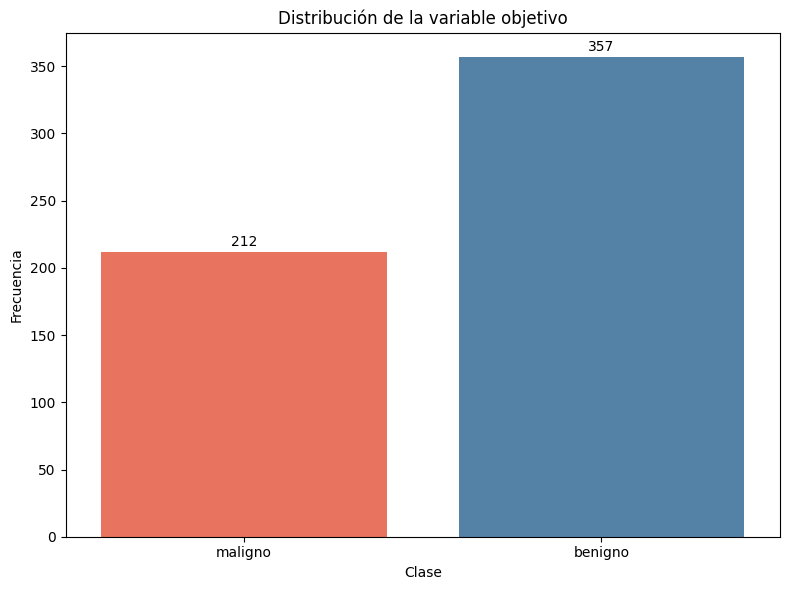

In [2]:
# Visualizar frecuencias de la variable objetivo
plt.figure(figsize=(8, 6))
ax = sns.countplot(
    data=df,
    x="target",   # 👈 CAMBIA AQUÍ, columna_a_modelar por el nombre de la columna a modelar
    hue="target", # 👈 CAMBIA AQUÍ, columna_a_modelar por el nombre de la columna a modelar
    palette={'maligno': 'tomato', 'benigno': 'steelblue'}
)
for container in ax.containers:
    ax.bar_label(container, label_type='edge', padding=2)
plt.title("Distribución de la variable objetivo")
plt.xlabel("Clase")
plt.ylabel("Frecuencia")
plt.tight_layout()

#### 🔍 2. Visualización por pares de algunas variables numéricas


Text(0.5, 1.02, 'Visualización por pares de variables')

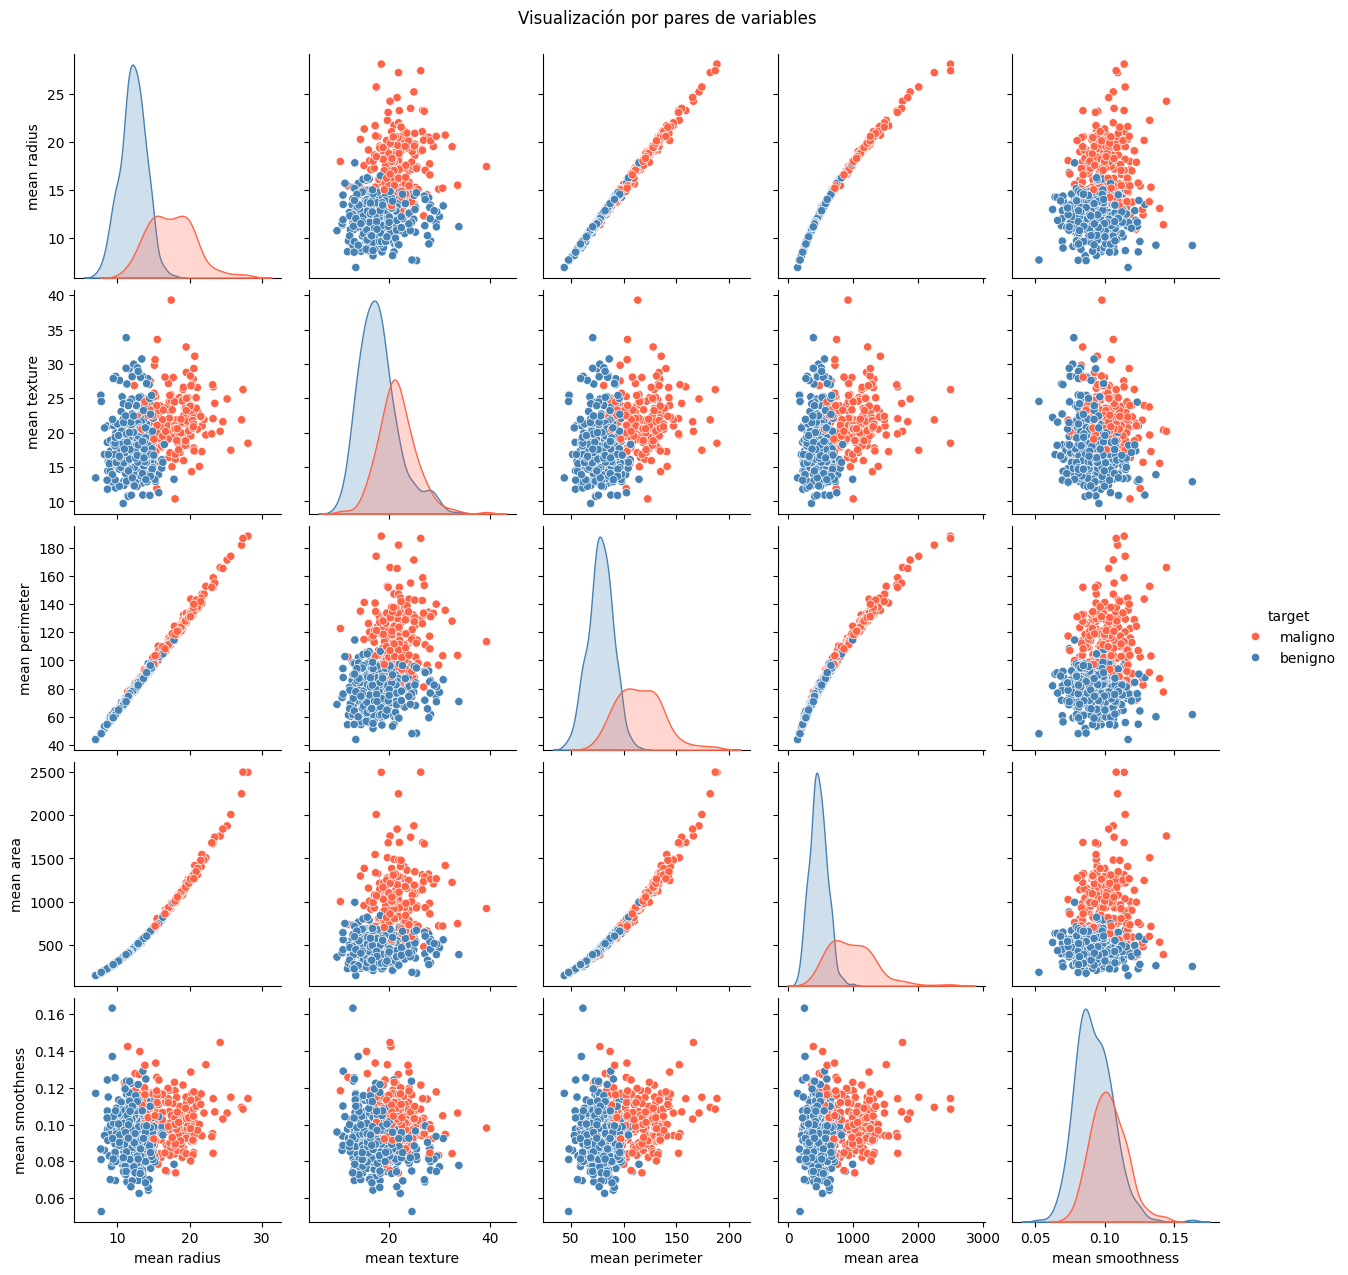

In [3]:
# Seleccionar algunas variables numéricas (puedes cambiar)
features = ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness']  # 👈 CAMBIA AQUÍ si deseas otras variables

# Pairplot para explorar relaciones entre variables
sns.pairplot(data=df[features + ['target']], hue='target', palette={'maligno': 'tomato', 'benigno': 'steelblue'})
plt.suptitle("Visualización por pares de variables", y=1.02)

#### 🧪 3. Separar conjunto de entrenamiento y prueba

In [ ]:
from sklearn.model_selection import train_test_split

# Definir variables X e y
X = df.drop(columns=['target'])  
y = df['target']

# Separar datos (ej. 70% entrenamiento, 30% prueba)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42  # 👈 CAMBIA AQUÍ el porcentaje si deseas
)

#### ⚙️ 4. Escalar los datos

In [5]:
from sklearn.preprocessing import StandardScaler

# Normalizar características numéricas
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # 👈 CAMBIA AQUÍ datos_de_entrenamiento, usa X_train
X_test_scaled = scaler.transform(X_test)  # 👈 CAMBIA AQUÍ datos_de_prueba, usa X_test

#### 🤖 5. Entrenar el modelo MLP

In [6]:
from sklearn.neural_network import MLPClassifier

# Crear y entrenar el modelo
mlp = MLPClassifier(hidden_layer_sizes=(6,), max_iter=1000, random_state=42)  # 👈 CAMBIA AQUÍ numero_de_nueronas por un valor numérico entero 
mlp.fit(X_train_scaled, y_train)

,hidden_layer_sizes,"(6,)"
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,1000
,shuffle,True
,random_state,42


#### 📊 6. Evaluación del modelo

In [7]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

# Realizar predicciones
y_pred = mlp.predict(X_test_scaled)  # 👈 CAMBIA AQUÍ test_data, usa X_test_scaled
y_pred

array(['benigno', 'maligno', 'benigno', 'maligno', 'benigno', 'benigno',
       'maligno', 'benigno', 'benigno', 'benigno', 'maligno', 'benigno',
       'maligno', 'benigno', 'benigno', 'benigno', 'benigno', 'benigno',
       'benigno', 'benigno', 'benigno', 'benigno', 'maligno', 'maligno',
       'maligno', 'benigno', 'benigno', 'maligno', 'maligno', 'maligno',
       'maligno', 'benigno', 'maligno', 'maligno', 'benigno', 'benigno',
       'benigno', 'benigno', 'maligno', 'benigno', 'benigno', 'benigno',
       'maligno', 'benigno', 'benigno', 'maligno', 'benigno', 'maligno',
       'benigno', 'benigno', 'maligno', 'maligno', 'benigno', 'benigno',
       'benigno', 'maligno', 'benigno', 'benigno', 'benigno', 'maligno',
       'benigno', 'benigno', 'maligno', 'benigno', 'benigno', 'benigno',
       'maligno', 'maligno', 'benigno', 'maligno', 'benigno', 'maligno',
       'maligno', 'benigno', 'benigno', 'benigno', 'benigno', 'maligno',
       'benigno', 'maligno', 'maligno', 'maligno', 


Reporte de clasificación:
               precision    recall  f1-score   support

     benigno       0.97      1.00      0.99        72
     maligno       1.00      0.95      0.98        42

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



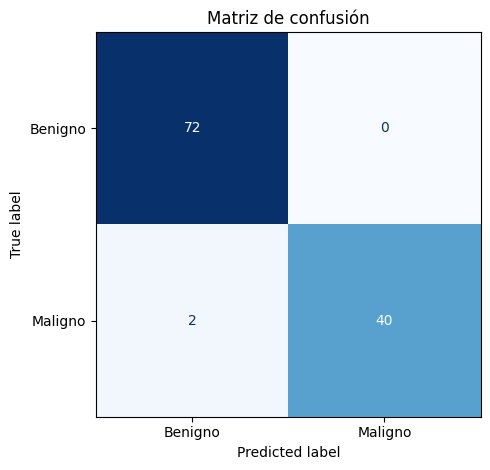

In [8]:
# Reporte de clasificación
print("\nReporte de clasificación:\n", classification_report(y_test, y_pred))

# Matriz de confusión
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=['Benigno', 'Maligno'], 
    cmap='Blues',
    colorbar=False
)
plt.title("Matriz de confusión")
plt.grid(False)
plt.tight_layout()



#### ✅ Recomendaciones finales

* Comenta cada bloque que modifiques.
* Puedes probar con diferentes:

  * Variables predictoras
  * Porcentajes de partición
  * Neuronas ocultas
  * Funciones de activación (`MLPClassifier(..., activation='relu')`)
 
#### Reflexión

Comente brevemente los resultados obtenidos: ¿el modelo clasificó correctamente la mayoría de los casos? ¿Qué métricas destacan? ¿Qué podría mejorar en una siguiente iteración?
 
